# 1. Imports and Reads

In [2]:
import json
import os
import pickle
import re
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from matplotlib import colors as mcolors
from src.utils.results_io import ResultsIO
from sklearn.metrics import mean_absolute_error, r2_score
from src.utils.feature_importance_utils import *

In [3]:
np.random.seed(42)

BASE_PATH = '../../Zenodo/data/2024-05-01_2024-05-14/'
BASE_DATA_PATH = '../../Zenodo/data/2024-05-01_2024-05-14/processed'
INPUT_CONFIG_PATH = '../../Zenodo/data/2024-05-01_2024-05-14/configs/POD/config_pretty.json'
RESULTS_BASE_PATH = "../../Zenodo/results/2024-05-01_2024-05-14/"
RESULTS_SUMMARY = "summary/"
STYLE_PATH = "../../workflow/manuscript.mplstyle"


# ignore the misinforming name (real units are m/day)
target = 'Orbital Decay (m) - without maneuvers'

satellite_configuration = json.load(open(INPUT_CONFIG_PATH))
satellites = list(satellite_configuration.keys())
icme_durations = json.load(open(os.path.join(BASE_PATH, 'CMEs', 'icme_durations_all_catalogs.json'), 'r'))

In [4]:
results_summaries = os.listdir(os.path.join(RESULTS_BASE_PATH, RESULTS_SUMMARY))

pattern = re.compile(r'_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}).pkl$')
most_recent_result = max([f for f in results_summaries if f.endswith('.pkl')], key=lambda f: os.path.getctime(os.path.join(RESULTS_BASE_PATH, RESULTS_SUMMARY, f)))
most_recent_timestamp = most_recent_result.split('_', 4)[-1].replace('.pkl', '')

scores_and_coef_dfs = pickle.load(open(os.path.join(RESULTS_BASE_PATH, RESULTS_SUMMARY, most_recent_result), 'rb'))
most_recent_grid_config = json.load(open(os.path.join(RESULTS_BASE_PATH, RESULTS_SUMMARY, f'reference_grid_config_{most_recent_timestamp}.json'), 'r'))
target_lags = most_recent_grid_config['target_lags_minutes']

## 1.1 Plot Utils

In [10]:
def apply_plotting_style(global_apply: bool = True, palette="deep"):
    if global_apply:
        sns.set_theme(style="whitegrid", rc={"grid.alpha": 0.25, "axes.grid": True})
        plt.style.use(str(STYLE_PATH))
        plt.rcParams['pdf.fonttype'] = 42
        sns.set_palette(palette)
        return None
    else:
        return plt.style.context(str(STYLE_PATH))

def add_panel_labels(axes, place='right', max_len=None):
    if not max_len:
        max_len = len(axes)

    panel_labels = [chr(ord('a') + i) for i in range(max_len)]
    for i in range(max_len):
        axes[i].text(0.98 if place =='right' else 0.02, 0.95, f"({panel_labels[i]})", transform=axes[i].transAxes, fontsize=10,fontweight="bold", va="top", ha=place)

def format_axes(ax, interval=2):
    locator = mdates.DayLocator(interval=interval)
    formatter = mdates.ConciseDateFormatter(locator, show_offset=True)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.grid(True, alpha=0.5)

def format_axes_and_legends(axes, a2, train_index, best_lag, ymax, nplots, annotate_train_size=True):
    for k in range(nplots):
        if annotate_train_size:
            ymax_axis = ymax
            ymin_axis = 0
            if k == 0:
                ymax_axis = axes[k].get_ylim()[1]
                ymin_axis = axes[k].get_ylim()[0]

            axes[k].vlines(train_index[-1], ymin=0, ymax=ymax, color='gray', label='Start of Test Period', alpha=0.5, linewidth=0.75)
            axes[k].vlines(train_index[-1] + pd.Timedelta(minutes=best_lag),  ymin=0, ymax=ymax,  color='gray',  linestyle='--', alpha=0.5, linewidth=0.75)

            for j in range(int(ymin_axis), int(ymax_axis), int(ymax_axis//10)):
                axes[k].hlines(y=j, xmin=train_index[-1], xmax=train_index[-1] + pd.Timedelta(minutes=best_lag),
                      color='gray', alpha=0.5)

            axes[k].set_ylim(ymin_axis,  ymax_axis)
            axes[k].set_xlabel("Time")

        format_axes(axes[k])

    handles, labels = axes[nplots-1].get_legend_handles_labels()
    if a2:
        a2.legend().remove()

    axes[0].legend().remove()
    by_label = dict(zip(labels, handles))
    axes[1].legend(by_label.values(), by_label.keys(), loc='lower center', bbox_to_anchor=(-0.17, -0.75), ncol=2, frameon=True, facecolor='white',
                   framealpha=0.5, fontsize=8, columnspacing=0.5, handletextpad=0.5)

def add_cme_and_lead(ax, cme_durations_json, ymin, ymax, best_lag, bcolor='gray', alpha=0.5):
    for c, catalog in enumerate(cme_durations_json):
        text = 'Time of ICME Start in situ - Wind (ICMECAT)' if 'Wind' in catalog else 'Time of geomagnetic storm sudden commencement (Richardson & Cane)' if 'RC' in catalog else 'Observed Interplanetary Shock Arrival Time (CCMC)'
        linestyle = '-.' if 'Wind' in catalog else '--' if 'RC' in catalog else ':'
        color = '#666666' if 'Wind' in catalog else '#7b9ff9' if 'RC' in catalog else '#D55E00'

        for k, event in enumerate(cme_durations_json[catalog]):
            cme_time = pd.to_datetime(event['arrival'])
            ax.vlines(cme_time, ymin=ymin, ymax=ymax, color=color,
                      linestyle=linestyle, label=text if k==0 else None, alpha=alpha,  linewidth=0.75)

            if ('RC' in catalog):# and (k == 2):
                ax.vlines(cme_time + pd.Timedelta(minutes=best_lag), ymin=ymin, ymax=ymax,
                      color=bcolor, linestyle='--', alpha=alpha,  linewidth=0.75)

                for j in range(int(ymin), int(ymax), int(ymax//10)):
                    ax.hlines(y=j, xmin=cme_time, xmax=cme_time + pd.Timedelta(minutes=best_lag),
                              color=bcolor, alpha=alpha)

def plot_results(io, cme_durations_json, col_to_plot=('|avg B|', '|avg B|'),
                 col2_to_plot=None,
                 best_lag=265, filepath='', cme_catalogs_to_plot=['L1_ICME_arrivals_RC'], show=False):
    apply_plotting_style()
    fig_width, fig_height = 6.8, 2
    ncols = 2
    cme_durations_json = {k: v for k, v in cme_durations_json.items() if k in cme_catalogs_to_plot}

    train_data, test_data = io.read_all()

    fig, axes = plt.subplots(1, ncols, figsize=(fig_width, fig_height), sharex=True, sharey=False)
    axes = axes.flatten()

    colors = [sns.color_palette("muted")[-1], sns.color_palette("Blues", n_colors=2)[1]]

    if col2_to_plot:
        a2 = axes[0].twinx()
    else:
        a2 = None

    for ax in axes:
        ax.set_xlim(train_data[0].index[0], test_data[0].index[-1])

    # Plot training features
    sns.lineplot(x=train_data[0].index, y=train_data[0][col_to_plot[0]], #label=col_to_plot[1],
                 color='black', alpha=0.5, linestyle=':', ax=axes[0], linewidth=1)

    sns.lineplot(x=test_data[0].index, y=test_data[0][col_to_plot[0]],  # label=col_to_plot[1],
                 color='black', alpha=1, linestyle='-', ax=axes[0], linewidth=1)

    axes[0].set_ylabel(col_to_plot[1])

    if col2_to_plot:
        sns.lineplot(x=train_data[0].index, y=train_data[0][col2_to_plot[0]],
                     color=colors[6], alpha=0.5, linestyle=':', ax=a2)

    if col2_to_plot:
        sns.lineplot(x=test_data[0].index, y=test_data[0][col2_to_plot[0]],
                     label=col2_to_plot[1], color=colors[6], alpha=1, linestyle='-', ax=a2)

    # Plot predictions and targets
    for df, label_suffix, alpha in zip([train_data, test_data],
                                       ['Train', 'Test'],
                                       [0.5, 1]):
        x_df, y_df, y_pred_df = df

        sns.lineplot(x=x_df.index + pd.Timedelta(minutes=best_lag),
                     y=y_df[io.target],
                     label=f'Decay Rate ({label_suffix} | Target)', #if label_suffix == 'Test' else None,
                     color=colors[0], alpha=alpha, linestyle='-' if label_suffix == 'Test' else ':', ax=axes[ncols-1], linewidth=1)

        sns.lineplot(x=x_df.index + pd.Timedelta(minutes=best_lag),
                     y=y_pred_df['y_pred'],
                     label=f'Decay Rate ({label_suffix} | Prediction)', # if label_suffix == 'Test' else None,
                     color=colors[1], alpha=alpha, linestyle='-' if label_suffix == 'Test' else ':', ax=axes[ncols-1], linewidth=1)


    axes[1].set_ylabel('Orbital Decay Rate ($\mathregular{m\ d^{-1}}$)')

    col_df_max = int(max(train_data[0][col_to_plot[0]].max(), test_data[0][col_to_plot[0]].max()))
    col_df_min = int(min(train_data[0][col_to_plot[0]].min(), test_data[0][col_to_plot[0]].min()))

    add_cme_and_lead(axes[0], cme_durations_json, col_df_min, col_df_max, best_lag)

    ymax = max(test_data[2]['y_pred'].max(), test_data[1][io.target].max()) + (test_data[1][io.target].max()//4)
    add_cme_and_lead(axes[ncols-1], cme_durations_json, 0, ymax, best_lag)

    ltime = train_data[0].index[-1]

    mid_time = ltime - pd.Timedelta(minutes=100)

    axes[ncols - 1].text(
        mid_time,
        ymax - (test_data[1][io.target].max()//5),
        f'|-| Prediction lead time\n of {best_lag} minutes', ha='left', fontsize=6,
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=2))

    format_axes_and_legends(axes, a2, train_data[0].index, best_lag, ymax, ncols)
    add_panel_labels(axes)

    plt.subplots_adjust(wspace=0.25)
    os.makedirs(filepath.rsplit('/', 1)[0], exist_ok=True)
    plt.savefig(filepath, dpi=600, bbox_inches='tight')
    if show:
        plt.show()

    plt.close()

In [6]:
def get_base_colors_for_alphabetical_sorted_features(feats):
    base_features = sorted(feats['feature'].apply(lambda x: re.sub(r'_\d+$', '', x)).unique())
    color_map = np.vstack([
        plt.cm.tab20(np.linspace(0, 1, 20)),
        plt.cm.tab20c(np.linspace(0, 1, 20))
    ])

    base_colors = {bf: color_map[i] for i, bf in enumerate(base_features)}
    base_colors['Others'] = (0.5, 0.5, 0.5)
    return base_colors

def lighten_color(color, amount=0.5):
    try:
        c = mcolors.cnames[color]
    except:
        c = color
    c = np.array(mcolors.to_rgb(c))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)

def plot_lasso_importance_with_stacked_lagged_inputs_black_and_white(feats, satellite, filepath, color, label='', xlim=None, show=False):
    apply_plotting_style()
    fig_width, fig_height = 6.8, 2
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))

    feats['base_feature'] = feats['feature'].apply(lambda x: re.sub(r'_\d+$', '', x))
    feats['lag'] = feats['feature'].apply(
        lambda x: int(re.search(r'_(\d+)$', x).group(1)) if re.search(r'_(\d+)$', x) else 0
    )
    feats = feats.sort_values(by=['base_feature', 'lag'])

    cum_importance = feats.groupby('base_feature')['Importance'].sum().sort_values(ascending=True)
    base_features_sorted = cum_importance.index.tolist()

    max_lag = feats['lag'].max() if feats['lag'].max() > 0 else 1
    bottoms = {bf: 0 for bf in base_features_sorted}
    for bf in base_features_sorted:
        for lag in sorted(feats['lag'].unique()):

            row = feats[(feats['base_feature'] == bf) & (feats['lag'] == lag)]
            if not row.empty:
                importance = row['Importance'].values[0]

                lighten_factor = lag / max_lag  # 0 lag = 0 (darkest), max lag = 1 (lightest)

                lag_color = lighten_color(color, amount=lighten_factor)

                plt.barh(bf, importance, left=bottoms[bf], color=lag_color,
                         edgecolor='lightgray', linewidth=0.5)

                if importance > 0.02:  # adjust threshold for readability
                    plt.text(bottoms[bf] + importance / 2, bf, str(lag),
                             ha='center', va='center', fontsize=7, color='black')

                bottoms[bf] += importance

    if xlim:
         plt.xlim(0, xlim)

    plt.xlabel(f'Normalized Importance ({label})')
    plt.title(f'Feature Importance for {satellite}')

    labels = [rf"{feature_to_physics_notation(bf)}" for bf in base_features_sorted]
    plt.yticks(ticks=base_features_sorted, labels=labels)

    os.makedirs(filepath.rsplit('/', 1)[0], exist_ok=True)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "Feature Lag",
        [lighten_color(color, 0), lighten_color(color, 1)]
    )

    norm = mpl.colors.Normalize(vmin=0, vmax=max_lag)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Feature Lag (minutes)")

    plt.savefig(filepath, dpi=600, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()

# 2. Inspect grid search results

Read the grid search results for all satellites and filter out the best models based on cross-validation MAE. Note that some models may have failed to converge, which is indicated in the 'notes' column of the results dataframe.

In [7]:
grid_config_path = most_recent_grid_config['grid_config_path'].replace('data', '../../Zenodo/data')
grid_path = grid_config_path.replace('configs/', 'outputs/').replace('.json', '_grid_all.csv').replace('grid_config_', '')
df = pd.read_parquet(grid_path)
df.head()

,satellite,n_splits,k,alpha_range,tol,best_alpha,n_iterations,mean_cv_MAE,mean_cv_r2,std_cv_r2,...,train_days,test_days,offset,whitelisted_features,selected_features,detrend,use_time_feature,input_lags,max_iter,notes
0,GFOC_RDCDFI,5,100,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.299670,915.0,5.660836,-4.002086,3.471594,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[AsyH (Omni), ap (LASP), |avg B|, Flow Speed (...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.
1,GFOC_RDCDFI,5,90,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.239976,1101.0,6.049480,-4.496684,3.330174,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[AsyH (Omni), ap (LASP), |avg B|, Flow Speed (...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.
2,GFOC_RDCDFI,5,80,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.246937,937.0,6.183595,-4.581161,3.396269,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[AsyH (Omni), ap (LASP), |avg B|, Flow Speed (...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.
3,GFOC_RDCDFI,5,150,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.181293,1006.0,7.238771,-4.977983,2.043526,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[SymH (Omni), AsyD (Omni), AsyH (Omni), ap (LA...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.
4,GFOC_RDCDFI,5,300,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.100110,1008.0,7.474335,-5.476607,3.764094,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[SymD (Omni), SymH (Omni), AsyD (Omni), AsyH (...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.


In [8]:
df = df[df['notes'].str.contains("success")].sort_values('mean_cv_MAE')
res = df.groupby('satellite').apply(lambda x: x.loc[x['mean_cv_MAE'].idxmin()])[['satellite', 'mean_cv_MAE', 'best_alpha', 'test_r2','selected_features', 'k', 'n_iterations']].reset_index(drop=True)
res['has_diff'] = res['selected_features'].apply(lambda x: any(['diff' in feat for feat in x]))
res.drop('selected_features', axis=1, inplace=True)
res

,satellite,mean_cv_MAE,best_alpha,test_r2,k,n_iterations,has_diff
0,GFOC_RDCDFI,5.660836,0.299670,0.575027,100,915.0,False
1,GFOD_RDDDFI,5.571723,0.299670,0.575587,100,830.0,False
2,S1A_RDAMFI24,2.007202,0.072587,-0.157753,40,203.0,False
3,S2A_RDAZFI24,2.192755,0.108359,-0.407513,100,278.0,False
4,S2B_RDAFFI24,2.538371,0.028871,-2.494086,60,663.0,False
5,S3A_RDAEFI24,2.141365,0.081454,0.241122,300,387.0,True
6,S3B_RDAEFI24,1.985389,0.044530,0.322866,40,289.0,False
7,S6A_RDAFFI24,4.156406,0.225892,-6.122077,150,202.0,False
8,SWMA_RDAWFI24,7.069833,0.235273,0.629317,70,639.0,False
9,SWMB_RDBWFI24,4.019399,0.287405,0.088805,80,467.0,False


# 3. Model results for best-performing models during CV per satellite

In [9]:
scores_table = []
for sat in satellites:

    io = ResultsIO(
        results_base_path=RESULTS_BASE_PATH,
        satellite=sat,
        most_recent_timestamp=most_recent_timestamp,
        target=most_recent_grid_config['target'],
        score_type='no_val'
    )
    X_train, y_train, y_train_pred = io.read(mode='train')
    X_test, y_test, y_pred = io.read(mode='test')

    for X, y, y_pred in [(X_train, y_train, y_train_pred), (X_test, y_test, y_pred)]:
        mae = mean_absolute_error(y, y_pred['y_pred'])
        r2 = r2_score(y, y_pred['y_pred'])
        r2_adjusted = 1 - (((1 - r2) * (len(y) - 1)) / (len(y) - X.shape[1] - 1))
        peak_error = abs(y[target].max() - y_pred['y_pred'].max())
        row = {
            'Satellite': satellite_configuration[sat]['name'],
            'MAE': f"{mae:.2f}",
            '$\overline{R}^2$': f"{r2_adjusted:.2f}",
            'Dataset' : 'Train' if X is X_train else 'Test',
            'Peak AE': f"{peak_error:.2f}",
            'Altitude': satellite_configuration[sat]["altitude"]
        }
        scores_table.append(row)
    # print(f"Satellite: {satellite_configuration[sat]['name']}; lead time: {target_lags[satellites.index(sat)]} minutes")

    scores_table.append({
        'Satellite': satellite_configuration[sat]['name'],
        'MAE': f"{res[res['satellite'] == sat]['mean_cv_MAE'].values[0]:.2f}",
        'R2 adjusted': 'N/A',
        'Peak AE': 'N/A',
        'Dataset' : 'Val (CV)',
        'Altitude': satellite_configuration[sat]["altitude"]
    })

to_drop = [
    ('R2 adjusted', 'Val (CV)'),
    ('Peak AE', 'Train'),
    ('Peak AE', 'Val (CV)')
]

scores_df = (
    pd.DataFrame(scores_table)
      .assign(Dataset=lambda d: pd.Categorical(
          d['Dataset'],
          categories=['Train', 'Val (CV)', 'Test'],
          ordered=True
      ))
      .pivot_table(index='Satellite',
                   columns='Dataset',
                   values=['$\overline{R}^2$', 'MAE', 'Peak AE'],
                   aggfunc='first')
      .drop(columns=to_drop, errors='ignore')
)

altitudes = pd.DataFrame(scores_table).drop_duplicates('Satellite').set_index('Satellite')['Altitude']
scores_df['Altitude'] = altitudes
scores_df = scores_df.sort_values('Altitude')
scores_df.drop('Altitude', axis=1, inplace=True)

print(scores_df.to_latex(float_format='{:.2f}'.format))

\begin{tabular}{lllllll}
\toprule
 & \multicolumn{2}{r}{$\overline{R}^2$} & \multicolumn{3}{r}{MAE} & Peak AE \\
Dataset & Train & Test & Train & Val (CV) & Test & Test \\
Satellite &  &  &  &  &  &  \\
\midrule
Swarm A & 0.84 & 0.63 & 2.80 & 7.07 & 17.55 & 0.03 \\
Swarm C & 0.80 & 0.59 & 3.04 & 6.24 & 17.38 & 37.90 \\
GRACE-FO C & 0.77 & 0.57 & 2.74 & 5.66 & 12.50 & 5.98 \\
GRACE-FO D & 0.77 & 0.57 & 2.74 & 5.57 & 12.48 & 4.00 \\
Swarm B & 0.51 & 0.08 & 1.98 & 4.02 & 17.50 & 82.41 \\
Sentinel 1A & 0.61 & -0.16 & 1.04 & 2.01 & 4.27 & 15.39 \\
Sentinel 2A & 0.76 & -0.42 & 0.94 & 2.19 & 4.37 & 0.66 \\
Sentinel 2B & 0.54 & -2.51 & 1.00 & 2.54 & 6.77 & 22.43 \\
Sentinel 3A & 0.64 & 0.23 & 0.92 & 2.14 & 3.21 & 3.89 \\
Sentinel 3B & 0.49 & 0.32 & 1.44 & 1.99 & 3.98 & 3.25 \\
Sentinel 6A & 0.51 & -6.18 & 1.54 & 4.16 & 5.06 & 7.49 \\
\bottomrule
\end{tabular}



# 4. Plot predictions

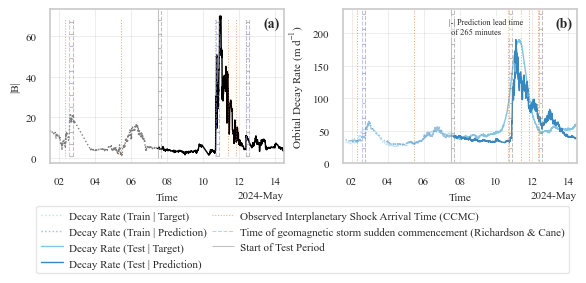

In [11]:
values_during_event = {}
for i, satellite in enumerate(satellites):
    if satellite not in scores_and_coef_dfs:
        print(f"No results for {satellite}, skipping...")
        continue

    io = ResultsIO(
        results_base_path=RESULTS_BASE_PATH,
        satellite=satellite,
        most_recent_timestamp=most_recent_timestamp,
        target=most_recent_grid_config['target']
    )
    results = io.read_results()

    top_scoring_lasso_feature = results[satellite]['no_val']['coefficients']['train'].sort_values(by='coef_abs', ascending=False).iloc[0]['feature']

    plot_results(io, icme_durations, best_lag=target_lags[i], col_to_plot=(top_scoring_lasso_feature, feature_to_physics_notation(top_scoring_lasso_feature)),
                 filepath=os.path.join(RESULTS_BASE_PATH, 'satellites', satellite, 'plots', f'predictions_{most_recent_timestamp}_{satellite}_results.pdf'), cme_catalogs_to_plot=[ 'L1_IPShock_arrivals_CCMC', 'L1_ICME_arrivals_RC'],#, 'Wind_ICME_arrivals_Mostl'],
                 show=satellite_configuration[satellite]['name'] == 'Swarm A')

# 5. Summarize feature importances

In [10]:
feats_all_sats = prepare_coefs_df(scores_and_coef_dfs)

low_alt_sats = [key for key in satellite_configuration.keys() if satellite_configuration[key]['altitude'] < 600]
grace_satellites = [key for key in satellite_configuration.keys() if 'GFO' in key]
swarm_ac_satellties = [key for key in satellite_configuration.keys() if 'SWMA' in key or 'SWMC' in key]
high_alt_sats = [sat for sat in satellites if sat not in low_alt_sats]

blacklist_idx = []

for sat_id, sat in enumerate(satellites):
    if scores_and_coef_dfs.get(sat) is None:
        if sat in low_alt_sats:
            low_alt_sats.remove(sat)
        if sat in high_alt_sats:
            high_alt_sats.remove(sat)
    else:
        r2 = scores_and_coef_dfs[sat]['no_val']['scores']['test']['R2']
        if r2 < 0.1:
            if sat in low_alt_sats:
                low_alt_sats.remove(sat)
            if sat in high_alt_sats:
                high_alt_sats.remove(sat)

    if sat_id in blacklist_idx:
        if sat in low_alt_sats:
            low_alt_sats.remove(sat)
        if sat in high_alt_sats:
            high_alt_sats.remove(sat)

unique_features = list(feats_all_sats['feature'].unique()) + ["Others"]
colors_by_feature = dict(zip(unique_features, sns.color_palette("tab20", len(unique_features))))

In [25]:
importance_text = {
    'lasso': 'Lasso',
    'shap': 'SHAP',
    'both': 'Combined SHAP and Lasso'
}
base_colors = get_base_colors_for_alphabetical_sorted_features(feats_all_sats)

for importance_kind in ['lasso', 'shap', 'both']:
    print(f"Processing importance kind: {importance_kind}")
    feats_low_alt = process_alt_feats(feats_all_sats, low_alt_sats, colors_by_feature, threshold=0.001, importance_kind=importance_kind)
    feats_high_alt = process_alt_feats(feats_all_sats, high_alt_sats, colors_by_feature, threshold=0.02, importance_kind=importance_kind)
    feats_grace = process_alt_feats(feats_all_sats, grace_satellites, colors_by_feature, threshold=0.001, importance_kind=importance_kind)
    feats_swarm_ac = process_alt_feats(feats_all_sats, swarm_ac_satellties, colors_by_feature, threshold=0.001, importance_kind=importance_kind)

    color = sns.color_palette("Blues", n_colors=2)[1]

    plot_lasso_importance_with_stacked_lagged_inputs_black_and_white(feats_low_alt, f'Satellites:\n{", ".join(list(map(lambda s: satellite_configuration[s]["name"], low_alt_sats)))}',
        filepath=os.path.join(RESULTS_BASE_PATH, 'summary', f'{most_recent_timestamp}_low_alt_importance_{importance_kind}_bw.pdf'), label=importance_text[importance_kind], color=color, xlim=0.4)

    plot_lasso_importance_with_stacked_lagged_inputs_black_and_white(feats_high_alt, 'Satellites:\n' + ', '.join(list(map(lambda s: satellite_configuration[s]["name"], high_alt_sats))),
        filepath=os.path.join(RESULTS_BASE_PATH, 'summary', f'{most_recent_timestamp}_high_alt_importance_{importance_kind}_bw.pdf'),
        label=importance_text[importance_kind], color=color, xlim=0.5)

Processing importance kind: lasso
Processing importance kind: shap
Processing importance kind: both


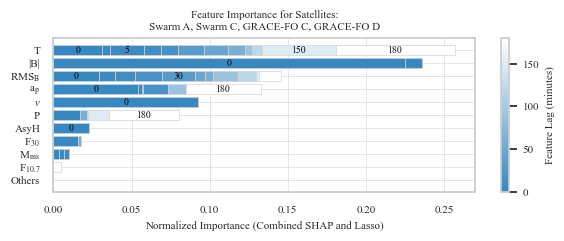

In [26]:
importance_kind = 'both'
feats_low_alt = process_alt_feats(feats_all_sats, low_alt_sats, colors_by_feature, threshold=0.001, importance_kind=importance_kind)
color = sns.color_palette("Blues", n_colors=2)[1]

plot_lasso_importance_with_stacked_lagged_inputs_black_and_white(feats_low_alt, f'Satellites:\n{", ".join(list(map(lambda s: satellite_configuration[s]["name"], low_alt_sats)))}',
    filepath=os.path.join(RESULTS_BASE_PATH, 'summary', f'{most_recent_timestamp}_low_alt_importance_{importance_kind}_bw.pdf'), label=importance_text[importance_kind], color=color, xlim=0.27, show=True)

In [27]:
sat = low_alt_sats[0]
print(sat)
results_for_sat = scores_and_coef_dfs[sat]

io = ResultsIO(
    results_base_path=RESULTS_BASE_PATH,
    satellite=sat,
    most_recent_timestamp=most_recent_timestamp,
    target=most_recent_grid_config['target'],
    score_type='no_val'
)
X_train, y_train, y_train_pred = io.read(mode='train')
X_test, y_test, y_pred = io.read(mode='test')

results = io.read_results()
coefficients = io.model[1].coef_
feature_names = X_train.columns

coef_df = pd.DataFrame({
        'feature': feature_names,
        'coef_signed': coefficients,
    })

len(X_train.columns), coefficients.shape
coefficients[coefficients < 0]
coef_df

SWMA_RDAWFI24


,feature,coef_signed
0,AsyH (Omni),0.536532
1,ap (LASP),0.239074
2,|avg B|,2.683284
3,Flow Speed (km/s,2.464045
4,Temperature (K),0.359075
...,...,...
87,ap (LASP)_180,0.970273
88,|avg B|_180,0.000000
89,Temperature (K)_180,1.091518
90,Flow pressure (nPa)_180,1.042399
